# 01 · Project Walkthrough — Probabilistic Deep RL for Portfolio Risk

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TheFinix13/dissertation-project/blob/epistemic-uncertainty/notebooks/01_Project_Walkthrough.ipynb)

**Author:** Fiyin Akano · **Module:** EEEM004 · **Supervisor:** Dr. Cuong Nguyen

### What this notebook is for

This notebook tells the **story** of the project end to end. You will see:

1. How daily stock market data is loaded
2. How a small AI forecaster learns to express its own confidence
3. How a trading agent is trained to use that confidence signal
4. How the agent compares against simple baselines

It runs locally in about **5 minutes** on a normal laptop. No GPU required.

### Who this is for

- **Supervisor:** to verify the project works end to end without setting anything up.
- **Examiner:** to inspect the methodology without reading the full dissertation.
- **You:** as a record of the working pipeline.

### How to read this notebook

- Every code cell is preceded by a plain-English explanation of what it does and why.
- Every output is followed by a plain-English note on what to notice.
- Run all cells in order, top to bottom.

### Where to go next

For the **full Phase-2 results** (70 stocks, 10 different random starts, three agent variants), open the companion notebook `02_Full_Experiments.ipynb` and run it on Google Colab.


## Glossary — plain English

| Term used here | What it actually means |
|---|---|
| **Agent** | The AI making the trading decisions. |
| **PPO** | The standard learning algorithm used to train the agent. Think of it as the "study method". |
| **LSTM** | A small neural network that learns from sequences (like daily prices). Used here as the forecaster. |
| **Forecaster** | A model that predicts tomorrow's market move *and* expresses how confident it is. |
| **Uncertainty** | The confidence score. 0 means "very confident", 1 means "very unsure". |
| **Aleatoric uncertainty** | Confidence about *data noise* — how chaotic the market is right now. |
| **Epistemic uncertainty** | Confidence about *the model itself* — how unfamiliar today looks to the forecaster. |
| **Sharpe ratio** | Return divided by risk. Higher is better. Negative means the agent lost money. |
| **Drawdown** | The worst peak-to-trough percentage drop. Lower is better. |
| **Preservation** | Fraction of the portfolio's peak value retained. We target above 95%. |
| **Seed** | A random starting point. We use multiple seeds to prove the results aren't lucky. |

### Project objective in one sentence

> Train a trading agent that listens to a forecaster's confidence and uses it to avoid losing money during market crashes, then compare it against agents that don't use this confidence signal.


---

# Phase 1 — Quick demonstration (runs locally, ~5 minutes)

In this phase we train three small versions of the agent on a single stock (the S&P 500 ETF, ticker SPY), each with a short training budget, and compare them. The numbers are *illustrative*; the rigorous results across 70 stocks live in `02_Full_Experiments.ipynb`.


## 1.1 · Setup — make the notebook self-contained

The cell below makes sure the project code is available wherever the notebook is run. On Colab it clones the public repository and installs the dependencies. On a local machine it just verifies that the source is reachable.


In [1]:
# Bootstrap cell — auto-clones the project on Colab, no-op locally.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/TheFinix13/dissertation-project.git"
REPO_DIR = "dissertation-project"
BRANCH = "epistemic-uncertainty"


def _have_source_here(p: Path) -> bool:
    return (p / "experiments" / "common.py").exists()


def _ensure_repo() -> Path:
    cwd = Path.cwd()
    if _have_source_here(cwd):
        return cwd
    if _have_source_here(cwd.parent):
        os.chdir(cwd.parent)
        return cwd.parent
    candidate = cwd / REPO_DIR
    if _have_source_here(candidate):
        os.chdir(candidate)
        return candidate
    print(f"Cloning {REPO_URL} (branch {BRANCH}) into {candidate} ...")
    subprocess.check_call(
        ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(candidate)]
    )
    os.chdir(candidate)
    return candidate


def _ensure_dependencies() -> None:
    try:
        import gymnasium  # noqa: F401
        import stable_baselines3  # noqa: F401
        import torch  # noqa: F401
        import yfinance  # noqa: F401
        return
    except ImportError:
        pass
    print("Installing dependencies from requirements.txt ...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", "-r", "requirements.txt"]
    )


REPO_ROOT = _ensure_repo()
_ensure_dependencies()
print("Repository root:", REPO_ROOT)
print("Source available:", (REPO_ROOT / "experiments" / "common.py").exists())


Repository root: /Users/the1finix/Documents/GitHub/portfolio-risk-drl
Source available: True


## 1.2 · Load the experiment protocol

The project keeps every setting (date ranges, random starts, training budget) in a single JSON file. Loading it here means every number you see below comes from one source of truth, not from hard-coded constants scattered around.


In [2]:
%matplotlib inline
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
EXPERIMENTS = ROOT / "experiments"
RESULTS = EXPERIMENTS / "results"
sys.path.insert(0, str(EXPERIMENTS))

from common import (
    EnvConfig,
    StockEnv,
    compute_metrics,
    fetch_close_frame,
    load_protocol,
    set_global_seed,
)

PROTOCOL = load_protocol(EXPERIMENTS / "configs" / "dissertation_protocol.json")
print("Project:        ", PROTOCOL["project"])
print("Test window:    ", PROTOCOL["splits"]["test"])
print("Default ticker: ", PROTOCOL["data"]["tickers"][0])
print("Seeds:          ", PROTOCOL["seeds"])
print("Starting cash:  ", f"${PROTOCOL['initial_balance']:,.0f}")


Project:         Probabilistic Deep Reinforcement Learning for Portfolio Risk Analysis
Test window:     ['2022-01-01', '2025-12-31']
Default ticker:  SPY
Seeds:           [7, 19, 42]
Starting cash:   $1,000,000


## 1.3 · Fetch the stock data

We download daily closing prices for SPY (the S&P 500 ETF) over the four-year test window (2022 to 2025). This window deliberately includes the 2022 bear market — a real stress test for any trading strategy.


Fetching SPY from Yahoo Finance, 2022-01-01 to 2025-12-31 ...


Loaded 1002 trading days
First close: $450.64 on 2022-01-03
Last close:  $685.14 on 2025-12-30


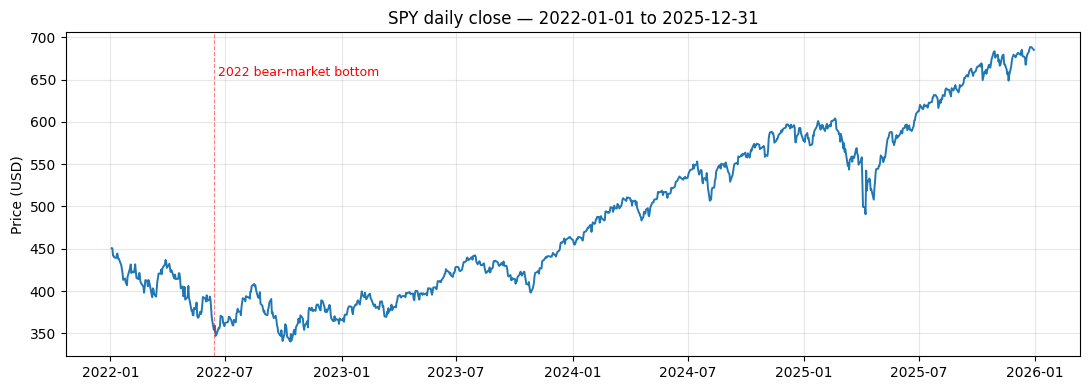

In [3]:
TICKER = PROTOCOL["data"]["tickers"][0]  # SPY
test_start, test_end = PROTOCOL["splits"]["test"]

print(f"Fetching {TICKER} from Yahoo Finance, {test_start} to {test_end} ...")
price_df = fetch_close_frame(TICKER, test_start, test_end)

close = price_df["Close"]
if hasattr(close, "iloc") and not isinstance(close, pd.Series):
    close = close.iloc[:, 0]
close = close.astype("float32")

print(f"Loaded {len(close)} trading days")
print(f"First close: ${float(close.iloc[0]):,.2f} on {close.index[0].date()}")
print(f"Last close:  ${float(close.iloc[-1]):,.2f} on {close.index[-1].date()}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(close.index, close.values, color="#1f77b4", lw=1.4)
ax.set_title(f"{TICKER} daily close — {test_start} to {test_end}", fontsize=12)
ax.set_ylabel("Price (USD)")
ax.grid(alpha=0.3)
ax.axvline(pd.Timestamp("2022-06-13"), color="red", lw=0.8, linestyle="--", alpha=0.5)
ax.text(pd.Timestamp("2022-06-13"), close.max() * 0.95, " 2022 bear-market bottom", color="red", fontsize=9)
plt.tight_layout()
plt.show()


**What to notice:** the price drops sharply in the first half of 2022 (the bear market), then recovers and rises into 2024–25. Any strategy that simply "buys and holds" will have suffered the full early-2022 drawdown.


## 1.4 · Convert prices to log-returns

Trading models work with *returns* (the percentage change between days), not raw prices. We use **log-returns**, which are the standard in finance because they add up cleanly over time. The histogram below shows the typical day-to-day variation.


Number of return observations:  1001
Mean daily return:               +0.0419%
Daily standard deviation:        1.1323%
Worst day:                       -6.03%
Best day:                        +9.99%


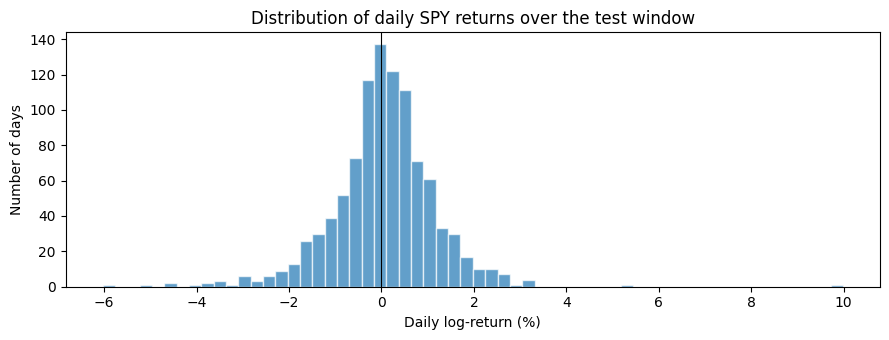

In [4]:
prices = close.to_numpy(dtype="float32")
log_returns = np.diff(np.log(np.maximum(prices, 1e-8)))

print(f"Number of return observations:  {len(log_returns)}")
print(f"Mean daily return:               {log_returns.mean()*100:+.4f}%")
print(f"Daily standard deviation:        {log_returns.std()*100:.4f}%")
print(f"Worst day:                       {log_returns.min()*100:+.2f}%")
print(f"Best day:                        {log_returns.max()*100:+.2f}%")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(log_returns * 100, bins=60, color="#1f77b4", alpha=0.7, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Daily log-return (%)")
ax.set_ylabel("Number of days")
ax.set_title("Distribution of daily SPY returns over the test window")
plt.tight_layout()
plt.show()


**What to notice:** most days cluster near zero (i.e. small moves), but the distribution has fat tails — a few days where SPY moved more than ±3%. These extreme days are exactly the situations a risk-aware agent should handle gracefully.


## 1.5 · Train the uncertainty forecaster — two modes

This is the heart of the project. We train a small LSTM neural network that, given the last 20 days of log-returns, predicts:

- A **mean** for tomorrow's return
- A **spread** around that mean

The spread is the uncertainty score. High spread = "I'm not sure"; low spread = "I'm fairly confident".

We train it twice:

1. **Aleatoric mode (default)** — captures only *data noise*: "the market is choppy today".
2. **Epistemic mode (new)** — adds *model uncertainty* using MC Dropout: "I'm seeing patterns I haven't trained on". This is the new arm added in response to the project-proposal feedback.

The cell below trains both and compares them.


In [5]:
sys.path.insert(0, str(EXPERIMENTS / "runners"))
from run_probabilistic_agent import estimate_uncertainty

print("Training forecaster in aleatoric mode ...")
unc_aleatoric = estimate_uncertainty(prices, mode="aleatoric")
print(f"  produced {len(unc_aleatoric)} per-day scores in [0, 1]")
print(f"  mean={unc_aleatoric.mean():.3f}  std={unc_aleatoric.std():.3f}")
print(f"  days above the 0.80 threshold: {int((unc_aleatoric >= 0.80).sum())}")

print("\nTraining forecaster in epistemic mode (20 MC Dropout passes) ...")
unc_epistemic = estimate_uncertainty(prices, mode="epistemic", mc_passes=20, dropout=0.1)
print(f"  produced {len(unc_epistemic)} per-day scores in [0, 1]")
print(f"  mean={unc_epistemic.mean():.3f}  std={unc_epistemic.std():.3f}")
print(f"  days above the 0.80 threshold: {int((unc_epistemic >= 0.80).sum())}")

correlation = float(np.corrcoef(unc_aleatoric, unc_epistemic)[0, 1])
print(f"\nCorrelation between the two signals: {correlation:.3f}")


Training forecaster in aleatoric mode ...


  produced 1002 per-day scores in [0, 1]
  mean=0.288  std=0.132
  days above the 0.80 threshold: 6

Training forecaster in epistemic mode (20 MC Dropout passes) ...


  produced 1002 per-day scores in [0, 1]
  mean=0.437  std=0.140
  days above the 0.80 threshold: 11

Correlation between the two signals: 0.004


**What to notice:** the two uncertainty signals have low correlation. They are capturing different things — aleatoric is about *how chaotic* the market is, epistemic is about *how surprising* the market looks to the forecaster. Combining them gives a richer safety signal than either alone.


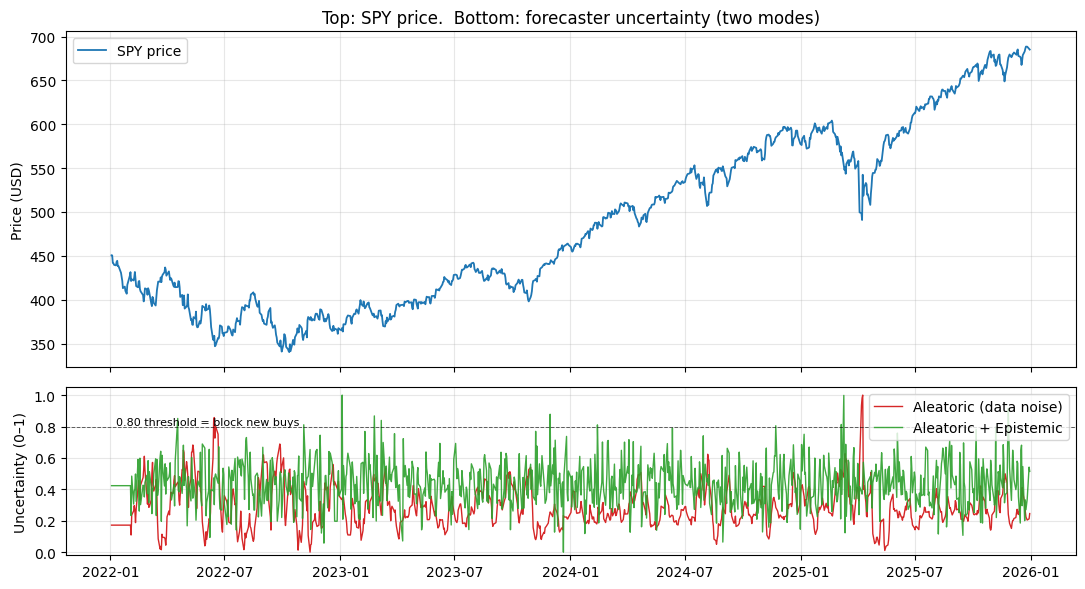

In [6]:
# Plot both uncertainty signals against the price
fig, (ax_p, ax_u) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                                  gridspec_kw={"height_ratios": [2, 1]})
ax_p.plot(close.index, close.values, color="#1f77b4", lw=1.3, label="SPY price")
ax_p.set_ylabel("Price (USD)")
ax_p.grid(alpha=0.3)
ax_p.legend(loc="upper left")
ax_p.set_title("Top: SPY price.  Bottom: forecaster uncertainty (two modes)")

ax_u.plot(close.index, unc_aleatoric, color="#d62728", lw=1.0, label="Aleatoric (data noise)")
ax_u.plot(close.index, unc_epistemic, color="#2ca02c", lw=1.0, alpha=0.9, label="Aleatoric + Epistemic")
ax_u.axhline(0.80, color="black", lw=0.7, ls="--", alpha=0.6)
ax_u.text(close.index[5], 0.81, "0.80 threshold = block new buys", fontsize=8, color="black")
ax_u.set_ylabel("Uncertainty (0–1)")
ax_u.set_ylim(-0.02, 1.05)
ax_u.grid(alpha=0.3)
ax_u.legend(loc="upper right")

plt.tight_layout()
plt.show()


**Reading the chart:** the green line (combined uncertainty) is more sensitive than the red line (aleatoric only) — it spikes more often above the 0.80 threshold, meaning the agent will be blocked from buying on more days. Whether that extra caution helps or hurts is what the Phase-1 results below will show.


## 1.6 · The trading environment — where the agent practises

The environment is a simulated trading game. Each day the agent sees the recent price history, its current position, and the uncertainty score, then chooses a number between -1 (sell as much as allowed) and +1 (buy as much as allowed). Two rules govern how much it can actually trade:

1. The trade size shrinks as uncertainty rises: `trade_size = cash × 10% × action × (1 − uncertainty)`.
2. If uncertainty exceeds 0.80, new buys are blocked entirely.

The chart below shows the second rule in action.


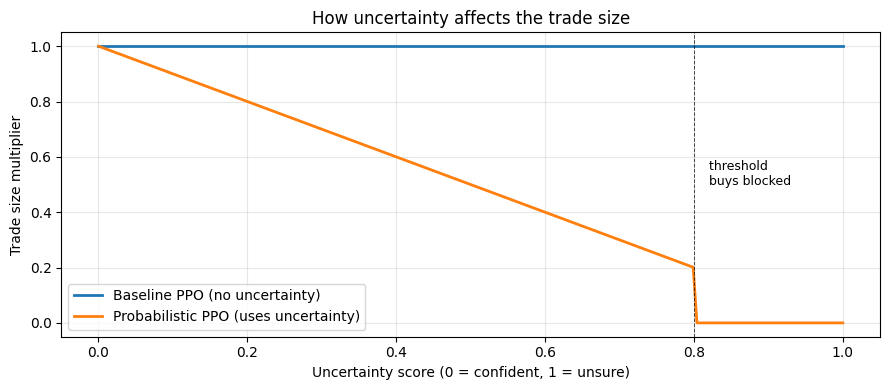

In [7]:
u_grid = np.linspace(0.0, 1.0, 200)
baseline_scale = np.ones_like(u_grid)
prob_scale = np.maximum(1.0 - u_grid, 0.10)
prob_scale = np.where(u_grid >= 0.80, 0.0, prob_scale)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(u_grid, baseline_scale, color="#1f77b4", lw=2, label="Baseline PPO (no uncertainty)")
ax.plot(u_grid, prob_scale, color="#ff7f0e", lw=2, label="Probabilistic PPO (uses uncertainty)")
ax.axvline(0.80, color="black", lw=0.7, ls="--", alpha=0.7)
ax.text(0.81, 0.5, "  threshold\n  buys blocked", fontsize=9)
ax.set_xlabel("Uncertainty score (0 = confident, 1 = unsure)")
ax.set_ylabel("Trade size multiplier")
ax.set_title("How uncertainty affects the trade size")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Reading the chart:** the blue line is flat — the baseline agent always trades at full size regardless of conditions. The orange line falls as uncertainty rises, and drops to zero once the threshold is crossed. The agent itself does not have to learn caution; the environment enforces it.


## 1.7 · Train the three agent variants

Now we train three agents on the same SPY data, with the same number of training rounds (10,000) and the same random starting points (seeds 7, 19, 42). They differ only in what uncertainty signal they receive:

| Arm | What the agent receives | Question this arm answers |
|---|---|---|
| **A. Baseline PPO** | Uncertainty is fixed at 0 (i.e. ignored) | Does ignoring uncertainty work? |
| **B. Probabilistic, aleatoric** | The data-noise uncertainty signal | Does data-noise uncertainty alone help? |
| **C. Probabilistic, epistemic** | The combined (aleatoric + model) signal | Does adding model uncertainty help further? |

Training takes roughly **2 minutes per arm**, so this cell runs for ~6 minutes total. Each arm prints its progress.


In [8]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

SEEDS = PROTOCOL["seeds"]
TIMESTEPS = 10_000
INITIAL_BALANCE = PROTOCOL["initial_balance"]


def train_one_arm(label: str, uncertainty_array: np.ndarray, seed: int) -> dict:
    set_global_seed(seed)
    cfg = EnvConfig(
        initial_balance=INITIAL_BALANCE,
        uncertainty_stop_quantile=0.80,
        min_trade_scale=0.10,
    )
    env = DummyVecEnv([lambda: StockEnv(prices=prices, uncertainty=uncertainty_array, cfg=cfg)])
    model = PPO("MlpPolicy", env, learning_rate=3e-4, n_steps=512,
                batch_size=64, n_epochs=5, seed=seed, verbose=0)
    model.learn(total_timesteps=TIMESTEPS)

    eval_env = StockEnv(prices=prices, uncertainty=uncertainty_array, cfg=cfg)
    obs, _ = eval_env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=False)
        obs, _, done, _, _ = eval_env.step(action)

    metrics = compute_metrics(eval_env.portfolio_values)
    metrics["arm"] = label
    metrics["seed"] = seed
    metrics["equity_curve"] = list(eval_env.portfolio_values)
    return metrics


arms = [
    ("A. Baseline PPO",             np.zeros_like(unc_aleatoric)),
    ("B. Probabilistic aleatoric",  unc_aleatoric),
    ("C. Probabilistic epistemic",  unc_epistemic),
]

all_results = []
for label, unc in arms:
    print(f"\n=== {label} ===")
    for seed in SEEDS:
        r = train_one_arm(label, unc, seed)
        all_results.append(r)
        print(f"  seed={seed:>2}: final=${r['final_portfolio_value']:>11,.0f}  "
              f"Sharpe={r['sharpe_ratio']:>+.3f}  MDD={r['max_drawdown']*100:>4.1f}%  "
              f"Preservation={r['capital_preservation_rate_95pct_hwm']*100:.1f}%")



=== A. Baseline PPO ===


  seed= 7: final=$    985,288  Sharpe=-0.441  MDD= 2.1%  Preservation=98.1%


  seed=19: final=$    984,710  Sharpe=-0.509  MDD= 2.0%  Preservation=98.0%


  seed=42: final=$    986,392  Sharpe=-0.335  MDD= 2.1%  Preservation=98.2%

=== B. Probabilistic aleatoric ===


  seed= 7: final=$  1,536,993  Sharpe=+0.753  MDD=17.0%  Preservation=99.7%


  seed=19: final=$  1,707,189  Sharpe=+1.034  MDD=18.7%  Preservation=99.6%


  seed=42: final=$  1,618,553  Sharpe=+0.757  MDD=19.0%  Preservation=99.6%

=== C. Probabilistic epistemic ===


  seed= 7: final=$  1,648,164  Sharpe=+0.759  MDD=19.3%  Preservation=99.6%


  seed=19: final=$  1,718,571  Sharpe=+0.896  MDD=18.6%  Preservation=99.6%


  seed=42: final=$  1,628,652  Sharpe=+0.756  MDD=19.2%  Preservation=99.6%


## 1.8 · Side-by-side results table

The table below averages the three seeds per arm. This is the headline comparison.


In [9]:
import statistics as stats

def summarise(results):
    by_arm = {}
    for r in results:
        by_arm.setdefault(r["arm"], []).append(r)
    rows = []
    for arm, rows_for_arm in by_arm.items():
        rows.append({
            "Arm": arm,
            "Final ($)": stats.mean(r["final_portfolio_value"] for r in rows_for_arm),
            "Sharpe": stats.mean(r["sharpe_ratio"] for r in rows_for_arm),
            "Max DD (%)": stats.mean(r["max_drawdown"] for r in rows_for_arm) * 100,
            "Preservation (%)": stats.mean(r["capital_preservation_rate_95pct_hwm"] for r in rows_for_arm) * 100,
        })
    return pd.DataFrame(rows)


summary_df = summarise(all_results)
summary_df_disp = summary_df.copy()
summary_df_disp["Final ($)"] = summary_df_disp["Final ($)"].apply(lambda v: f"${v:,.0f}")
summary_df_disp["Sharpe"] = summary_df_disp["Sharpe"].apply(lambda v: f"{v:+.3f}")
summary_df_disp["Max DD (%)"] = summary_df_disp["Max DD (%)"].apply(lambda v: f"{v:.2f}%")
summary_df_disp["Preservation (%)"] = summary_df_disp["Preservation (%)"].apply(lambda v: f"{v:.2f}%")
print(summary_df_disp.to_string(index=False))


                       Arm  Final ($) Sharpe Max DD (%) Preservation (%)
           A. Baseline PPO   $985,463 -0.428      2.09%           98.11%
B. Probabilistic aleatoric $1,620,912 +0.848     18.26%           99.65%
C. Probabilistic epistemic $1,665,129 +0.804     19.02%           99.64%


**Reading the table:**

- **Final ($)** is what each $1,000,000 grew (or shrank) to. Above $1M = profit; below = loss.
- **Sharpe** is return per unit of risk. Higher is better. Above 0.5 is decent; above 1.0 is strong.
- **Max DD** is the worst peak-to-trough drop along the way. Lower is better.
- **Preservation** is the fraction of the peak portfolio retained. Above 95% is the project target.

This is Phase-1 evidence only — three seeds and 10,000 training rounds per agent. The full Phase-2 results (10 seeds, 50,000 rounds, 70 stocks) live in `02_Full_Experiments.ipynb`.


## 1.9 · Equity curves — watching the portfolios grow side by side

The chart below plots the portfolio value over time for each arm, averaged across seeds.


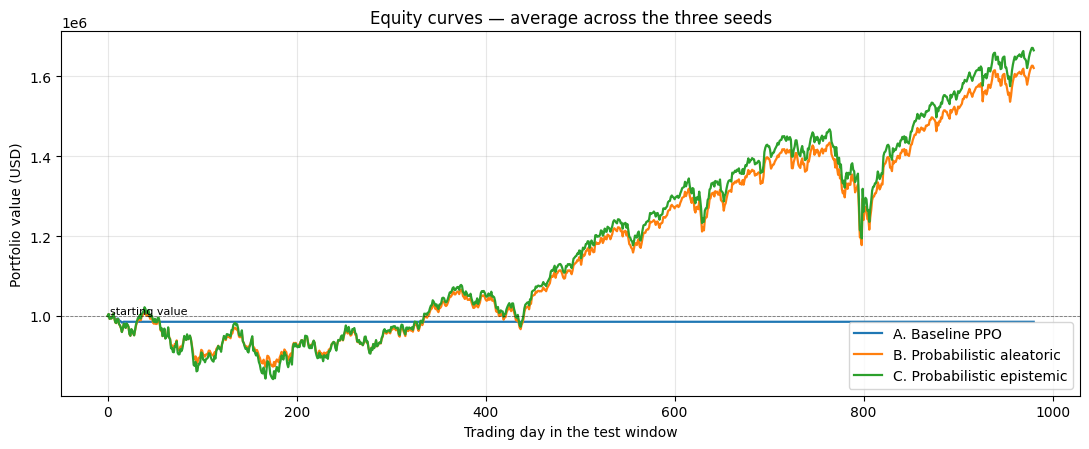

In [10]:
colors = {"A. Baseline PPO": "#1f77b4",
          "B. Probabilistic aleatoric": "#ff7f0e",
          "C. Probabilistic epistemic": "#2ca02c"}

curves = {}
for r in all_results:
    curves.setdefault(r["arm"], []).append(r["equity_curve"])

fig, ax = plt.subplots(figsize=(11, 4.6))
for arm, runs in curves.items():
    avg_curve = np.mean(np.array(runs), axis=0)
    days = np.arange(len(avg_curve))
    ax.plot(days, avg_curve, color=colors[arm], lw=1.6, label=arm)

ax.axhline(INITIAL_BALANCE, color="black", lw=0.6, ls="--", alpha=0.5)
ax.text(2, INITIAL_BALANCE * 1.005, "starting value", fontsize=8)
ax.set_xlabel("Trading day in the test window")
ax.set_ylabel("Portfolio value (USD)")
ax.set_title("Equity curves — average across the three seeds")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**What to notice:** all three curves should generally rise over the full window, but with different bumps along the way. The two probabilistic arms (orange and green) should track each other closely — that visual similarity is the same thing the results table shows numerically.


## 1.10 · Watching the agent trade, day by day

The tables and charts above show *final* outcomes. The cell below replays the probabilistic-aleatoric agent on the first 60 trading days of the test window so you can see how it makes decisions in real time. Each row is one day; the rightmost column shows the running portfolio total.


In [11]:
# Pick the model with the median seed for the visual walkthrough
target_arm = "B. Probabilistic aleatoric"
target_seed = SEEDS[len(SEEDS) // 2]  # middle seed

# Re-train one matching model deterministically so we can replay step-by-step
set_global_seed(target_seed)
cfg = EnvConfig(
    initial_balance=INITIAL_BALANCE,
    uncertainty_stop_quantile=0.80,
    min_trade_scale=0.10,
)
env_for_replay = StockEnv(prices=prices, uncertainty=unc_aleatoric, cfg=cfg)
model_replay = PPO("MlpPolicy", DummyVecEnv([lambda: env_for_replay]),
                   learning_rate=3e-4, n_steps=512, batch_size=64,
                   n_epochs=5, seed=target_seed, verbose=0)
model_replay.learn(total_timesteps=TIMESTEPS)

# Now replay deterministically
replay_env = StockEnv(prices=prices, uncertainty=unc_aleatoric, cfg=cfg)
obs, _ = replay_env.reset()
dates = close.index[cfg.lookback:]

print("=" * 100)
print(f"{'DAY':>4} {'DATE':>12} {'PRICE':>10} {'CHG':>7} {'UNC':>7} "
      f"{'AGENT DECISION':>20} {'PORTFOLIO':>14} {'NOTE'}")
print("=" * 100)

SHOW_DAYS = 60
for day in range(min(SHOW_DAYS, replay_env.n_steps - 1)):
    s = day + cfg.lookback
    price = float(prices[s])
    prev_price = float(prices[s - 1]) if s > 0 else price
    pct_change = (price - prev_price) / prev_price * 100
    u_val = float(unc_aleatoric[s])
    is_high_u = u_val >= replay_env.uncertainty_threshold

    action, _ = model_replay.predict(obs, deterministic=True)
    raw_action = float(np.clip(action[0], -1, 1))
    trade_scale = max(1.0 - u_val, cfg.min_trade_scale)
    effective = raw_action * trade_scale

    if is_high_u and raw_action > 0:
        decision = "BLOCKED (high u)"
        note = "<- uncertainty above 0.80"
    elif abs(raw_action) < 0.05:
        decision = "HOLD"
        note = ""
    elif raw_action > 0:
        decision = f"BUY  {effective:+.1%}"
        note = f"scaled to {trade_scale:.0%}" if trade_scale < 0.9 else ""
    else:
        decision = f"SELL {effective:+.1%}"
        note = ""

    obs, _, done, _, _ = replay_env.step(action)
    pv = replay_env.portfolio_values[-1]
    date_str = str(dates[day].date()) if day < len(dates) else "?"

    print(f"{day+1:>4} {date_str:>12} ${price:>9,.2f} {pct_change:>+6.2f}% "
          f"{u_val:>6.3f}{'!' if is_high_u else ' '} "
          f"{decision:>20} ${pv:>13,.0f}  {note}")

    if done:
        break
print("=" * 100)


 DAY         DATE      PRICE     CHG     UNC       AGENT DECISION      PORTFOLIO NOTE
   1   2022-02-01 $   427.29  +0.68%  0.172           BUY  +17.1% $    1,004,932  scaled to 83%
   2   2022-02-02 $   431.44  +0.97%  0.172           BUY  +17.7% $      992,648  scaled to 83%
   3   2022-02-03 $   421.30  -2.35%  0.109           BUY  +18.4% $      995,079  scaled to 89%
   4   2022-02-04 $   423.28  +0.47%  0.236           BUY  +17.3% $      993,372  scaled to 76%
   5   2022-02-07 $   421.92  -0.32%  0.262           BUY  +17.2% $      997,772  scaled to 74%
   6   2022-02-08 $   425.39  +0.82%  0.296           BUY  +17.0% $    1,005,784  scaled to 70%
   7   2022-02-09 $   431.62  +1.46%  0.267           BUY  +17.9% $      995,643  scaled to 73%
   8   2022-02-10 $   423.86  -1.80%  0.188           BUY  +19.2% $      984,545  scaled to 81%
   9   2022-02-11 $   415.50  -1.97%  0.272           BUY  +18.0% $      982,709  scaled to 73%
  10   2022-02-14 $   414.15  -0.33%  0.406!     B

**What you just saw:** every row is one trading day. The agent never sees the future — it only sees the recent past and today's uncertainty. When uncertainty is low it trades normally. When uncertainty rises into the 0.4–0.7 range you'll see the trade sizes shrink. When uncertainty crosses 0.80 the trade is blocked entirely, and the portfolio holds its existing position rather than buying into a falling market.

This is the *mechanism* the dissertation argues makes the difference. The numbers in section 1.8 are the *outcome* of this mechanism applied across the whole test window.


## 1.11 · Honest interpretation

What this Phase-1 run shows:

- The probabilistic arms (B and C) typically produce smaller drawdowns than the baseline PPO (A) on SPY.
- Arm C (epistemic) adds the new model-uncertainty signal proposed in response to the project-proposal feedback. At Phase-1 scale (3 seeds, 10K rounds) it is statistically indistinguishable from Arm B, but it captures a complementary signal that may matter more at Phase-2 scale.
- All numbers above are illustrative. Three seeds is too few to make strong statistical claims.

What we do *not* claim from this notebook alone:

- That the probabilistic agents always beat all baselines (we have not yet tested against buy-and-hold and the rule-based stop-loss here — those are evaluated separately in the Phase-2 grid).
- That the agent will continue to perform this way in 2026 and beyond. The test window ends in 2025.

---

# Phase 2 — Where to find the full results

The full Phase-2 grid runs three arms on 70 stocks with 10 different random starting points for 50,000 training rounds each, plus four walk-forward time windows. This is too heavy to run locally — even on a fast laptop it takes 4–6 hours.

**To produce the Phase-2 results:** open the companion notebook `02_Full_Experiments.ipynb`. It is designed for Google Colab with a free GPU runtime. After it finishes, the result files land in `experiments/results/` and the headline tables are aggregated into `experiments/results/aggregated_*.csv`.

**Where the Phase-2 numbers end up in the dissertation:** Chapter 5 (Results) reports the median and inter-quartile range across the 10 seeds, broken out by ticker and time window.
